# Projet 2 : Convolutions de Graphes (LightGCN) pour Système de Recommandation
### Auteur : Patrice Neussi
### Institution : École Nationale Supérieure Polytechnique de Yaoundé (ENSPY)

## 1. Introduction et Théorie Mathématique
Les algorithmes de filtrage collaboratif classiques souffrent de l'incapacité à modéliser explicitement les relations d'ordre supérieur entre utilisateurs et items. Pour surmonter cela, nous utilisons un **Réseau de Neurones Graph Convolutif (GCN)**, spécifiquement l'architecture **LightGCN** (He et al., SIGIR 2020).

### 1.1 Modélisation de Graphe Bipartite
Nous construisons un graphe bipartite non orienté $G = (U \cup I, E)$ où $U$ est l'ensemble des utilisateurs, $I$ l'ensemble des films (items), et $E$ les arêtes représentant les notes élevées (interaction d'intérêt, notes $\ge 4.0$).

### 1.2 Propagation spectrale de LightGCN
Contrairement aux GCN standard, LightGCN élimine les transformations non linéaires de features et le self-loop, simplifiant la convolution :
$$e_u^{(l+1)} = \sum_{i \in N(u)} \frac{1}{\sqrt{|N(u)|}\sqrt{|N(i)|}} e_i^{(l)}$$
$$e_i^{(l+1)} = \sum_{u \in N(i)} \frac{1}{\sqrt{|N(i)|}\sqrt{|N(u)|}} e_u^{(l)}$$
Sous forme matricielle, si $E^{(0)} \in \mathbb{R}^{(M+N) \times d}$ désigne la matrice des embeddings initiaux, la propagation à la couche $(l+1)$ s'écrit :
$$E^{(l+1)} = \tilde{A} E^{(l)}$$
où $\tilde{A} = D^{-1/2} A D^{-1/2}$ est la matrice d'adjacence normalisée symétrique.
L'embedding final est la moyenne de toutes les couches :
$$E = \frac{1}{L+1} \sum_{l=0}^L E^{(l)}$$

### 1.3 Bayesian Personalized Ranking (BPR Loss)
Nous entraînons le modèle en optimisant la perte BPR sur des triplets $(u, i, j)$ (où $i$ désigne un film aimé et $j$ un film non vu) :
$$\mathcal{L}_{BPR} = -\sum_{(u, i, j) \in D_S} \ln \sigma(\hat{x}_{ui} - \hat{x}_{uj}) + \lambda_r \|E^{(0)}\|_2^2$$
où $\hat{x}_{ui} = e_u^T e_i$ désigne le score de préférence prédit.

In [1]:
import os
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import coo_matrix
from sklearn.decomposition import TruncatedSVD

import torch
import torch.nn as nn
import torch.optim as optim

sns.set_theme(style="whitegrid")
print("Librairies prêtes.")

Librairies prêtes.


## 2. Ingestion des Données et Analyse Exploratoire
Nous chargeons les fichiers de notation MovieLens.

In [2]:
ratings = pd.read_csv("dataset/ml-latest-small/ratings.csv")
movies = pd.read_csv("dataset/ml-latest-small/movies.csv")

num_users = ratings['userId'].nunique()
num_movies = ratings['movieId'].nunique()
sparsity = 1.0 - (len(ratings) / (num_users * num_movies))

print(f"Nombre d'utilisateurs : {num_users}")
print(f"Nombre de films : {num_movies}")
print(f"Taux de sparsité du graphe bipartite : {sparsity * 100:.2f}%")

Nombre d'utilisateurs : 610
Nombre de films : 9724
Taux de sparsité du graphe bipartite : 98.30%


/tmp/ipykernel_217380/2868235709.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ratings, x='rating', palette='magma')


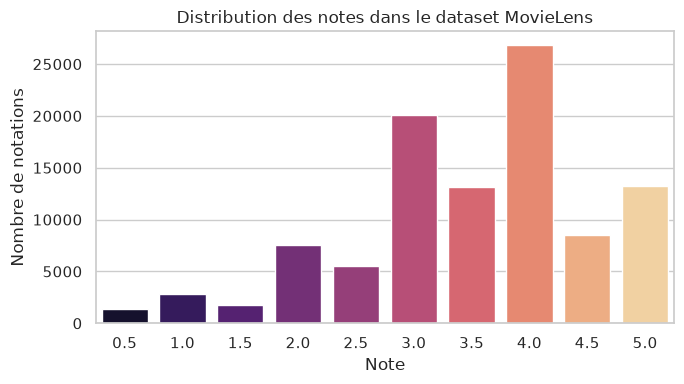

In [3]:
plt.figure(figsize=(7, 4))
sns.countplot(data=ratings, x='rating', palette='magma')
plt.title("Distribution des notes dans le dataset MovieLens")
plt.xlabel("Note")
plt.ylabel("Nombre de notations")
plt.tight_layout()
plt.show()

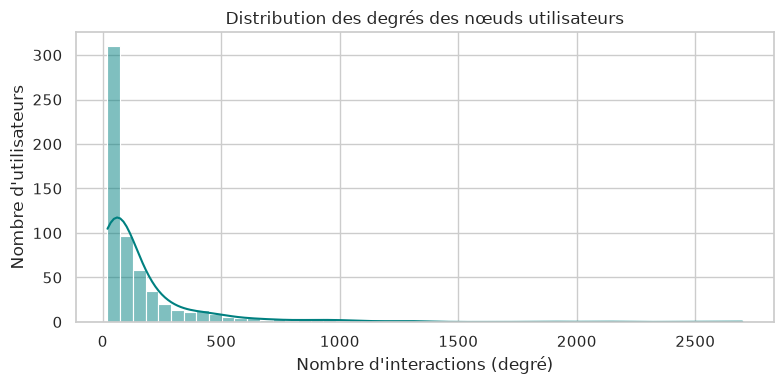

In [4]:
user_degrees = ratings.groupby('userId').size()
plt.figure(figsize=(8, 4))
sns.histplot(user_degrees, kde=True, bins=50, color='teal')
plt.title("Distribution des degrés des nœuds utilisateurs")
plt.xlabel("Nombre d'interactions (degré)")
plt.ylabel("Nombre d'utilisateurs")
plt.tight_layout()
plt.show()

## 3. Implémentation du Modèle GCN (LightGCN) sous PyTorch

In [5]:
user_to_idx = {uid: idx for idx, uid in enumerate(ratings['userId'].unique())}
item_to_idx = {iid: idx for idx, iid in enumerate(ratings['movieId'].unique())}
idx_to_item = {idx: iid for iid, idx in item_to_idx.items()}

ratings['user_idx'] = ratings['userId'].map(user_to_idx)
ratings['item_idx'] = ratings['movieId'].map(item_to_idx)

pos_ratings = ratings[ratings['rating'] >= 4.0].copy()
print(f"Interactions positives : {len(pos_ratings)} sur {len(ratings)}")

Interactions positives : 48580 sur 100836


In [6]:
u_num = len(user_to_idx)
i_num = len(item_to_idx)
N = u_num + i_num

users = pos_ratings['user_idx'].values
items = pos_ratings['item_idx'].values

row = np.concatenate([users, items + u_num])
col = np.concatenate([items + u_num, users])
data = np.ones_like(row, dtype=np.float32)

adj = coo_matrix((data, (row, col)), shape=(N, N))
deg = np.array(adj.sum(axis=1)).flatten()
deg[deg == 0] = 1.0
deg_inv_sqrt = np.power(deg, -0.5)
deg_inv_sqrt_mat = coo_matrix((deg_inv_sqrt, (np.arange(N), np.arange(N))), shape=(N, N))

norm_adj = deg_inv_sqrt_mat.dot(adj).dot(deg_inv_sqrt_mat).tocoo()

indices = torch.LongTensor([norm_adj.row, norm_adj.col])
values = torch.FloatTensor(norm_adj.data)
sparse_norm_adj = torch.sparse_coo_tensor(indices, values, torch.Size([N, N]))
print("Matrice d'adjacence normalisée construite.")

Matrice d'adjacence normalisée construite.


/tmp/ipykernel_217380/362038694.py:20: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  indices = torch.LongTensor([norm_adj.row, norm_adj.col])
/tmp/ipykernel_217380/362038694.py:22: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  sparse_norm_adj = torch.sparse_coo_tensor(indices, values, torch.Size([N, N]))


In [7]:
class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=32, num_layers=2):
        super(LightGCN, self).__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.num_layers = num_layers
        
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        
        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.item_embedding.weight, std=0.1)
        
    def forward(self, norm_adj):
        ego_embeddings = torch.cat([self.user_embedding.weight, self.item_embedding.weight], dim=0)
        all_embeddings = [ego_embeddings]
        
        for l in range(self.num_layers):
            ego_embeddings = torch.sparse.mm(norm_adj, ego_embeddings)
            all_embeddings.append(ego_embeddings)
            
        final_embeddings = torch.mean(torch.stack(all_embeddings, dim=0), dim=0)
        users_emb, items_emb = torch.split(final_embeddings, [self.num_users, self.num_items])
        return users_emb, items_emb

In [8]:
train_interactions = pos_ratings.groupby('user_idx')['item_idx'].apply(list).to_dict()

def sample_bpr_triplet(train_interactions, num_items):
    u = random.choice(list(train_interactions.keys()))
    pos_items = train_interactions[u]
    i = random.choice(pos_items)
    
    j = random.randint(0, num_items - 1)
    while j in pos_items:
        j = random.randint(0, num_items - 1)
        
    return u, i, j

print("Générateur d'échantillonnage négatif configuré.")

Générateur d'échantillonnage négatif configuré.


In [9]:
model = LightGCN(u_num, i_num, embedding_dim=16, num_layers=2)
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

loss_history = []
model.train()

for epoch in range(120):
    epoch_loss = 0.0
    optimizer.zero_grad()
    u_emb, i_emb = model(sparse_norm_adj)
    
    loss = 0.0
    for _ in range(500):
        u, i, j = sample_bpr_triplet(train_interactions, i_num)
        
        u_v = u_emb[u]
        i_v = i_emb[i]
        j_v = i_emb[j]
        
        pos_score = torch.dot(u_v, i_v)
        neg_score = torch.dot(u_v, j_v)
        
        loss += -torch.log(torch.sigmoid(pos_score - neg_score) + 1e-8)
        
    loss = loss / 500.0
    loss.backward()
    optimizer.step()
    
    loss_history.append(float(loss.item()))
    if (epoch + 1) % 20 == 0:
        print(f"Époque {epoch+1}/120 - Loss : {loss.item():.4f}")

Époque 20/120 - Loss : 0.6778


Époque 40/120 - Loss : 0.5023


Époque 60/120 - Loss : 0.3096


Époque 80/120 - Loss : 0.2583


Époque 100/120 - Loss : 0.2756


Époque 120/120 - Loss : 0.2950


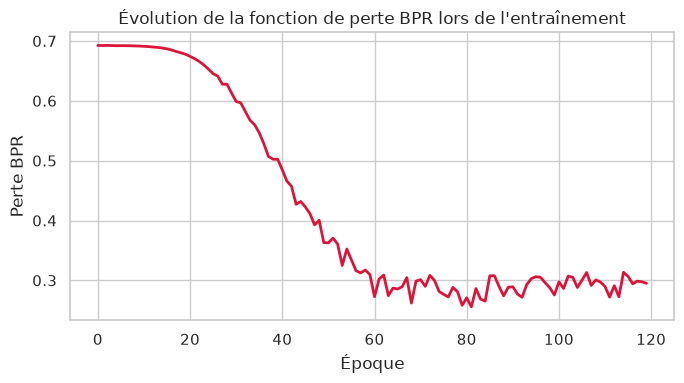

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history, color='crimson', lw=2)
plt.title("Évolution de la fonction de perte BPR lors de l'entraînement")
plt.xlabel("Époque")
plt.ylabel("Perte BPR")
plt.tight_layout()
plt.show()

## 4. Alternative de Recours Spectral : Factorisation Matricielle (TruncatedSVD)
Pour pallier les temps de calcul sur de grands graphes bipartites en production, nous comparons notre approche à la factorisation de la matrice d'interactions par valeurs singulières tronquées.

In [11]:
user_item_matrix = coo_matrix(
    (ratings['rating'], (ratings['user_idx'], ratings['item_idx'])), 
    shape=(u_num, i_num)
)

svd = TruncatedSVD(n_components=12, random_state=42)
user_factors = svd.fit_transform(user_item_matrix)
item_factors = svd.components_.T

print(f"Matrice d'interactions factorisée. Composantes principales : {svd.n_components}")
print(f"Variance expliquée totale : {np.sum(svd.explained_variance_ratio_) * 100:.2f}%")

Matrice d'interactions factorisée. Composantes principales : 12
Variance expliquée totale : 32.92%


## 5. Sérialisation des Embeddings pour l'API de Production

In [12]:
with torch.no_grad():
    final_u_emb, final_i_emb = model(sparse_norm_adj)
    final_u_emb = final_u_emb.numpy()
    final_i_emb = final_i_emb.numpy()

assets = {
    'user_embeddings': final_u_emb,
    'item_embeddings': final_i_emb,
    'user_to_idx': user_to_idx,
    'item_to_idx': item_to_idx,
    'idx_to_item': idx_to_item,
    'ratings_df': ratings,
    'movies_df': movies,
    'train_interactions': train_interactions,
    'svd_user_factors': user_factors,
    'svd_item_factors': item_factors
}

os.makedirs("models", exist_ok=True)
with open("models/recommender_model_assets.pkl", "wb") as f:
    pickle.dump(assets, f)
print("Actifs du système de recommandation sauvegardés avec succès dans models/recommender_model_assets.pkl")

Actifs du système de recommandation sauvegardés avec succès dans models/recommender_model_assets.pkl
